# 03. Computer Vision with PyTorch & Convolutional Neural Networks

### Overview & Core Concepts
* **PyTorch Vision Ecosystem:** Leveraging `torchvision.datasets` (e.g., FashionMNIST), image preprocessing and augmentations via `torchvision.transforms`, and batched asynchronous loading with `torch.utils.data.DataLoader`.
* **Tensor Layouts & Input Formatting:** Navigating vision tensor dimensional conventions ($NCHW$ vs. $NHWC$) across single/multi-channel image inputs.
* **Architectural Progression & Benchmarking:**
  * **Model 0 (Baseline):** Dense linear baseline with flattened spatial inputs (`nn.Flatten`).
  * **Model 1 (Non-Linear):** Multi-layer perceptron incorporating non-linear activations (`nn.ReLU`).
  * **Model 2 (TinyVGG CNN):** Convolutional feature extraction stack with spatial convolutions (`nn.Conv2d`), activations, downsampling via max pooling (`nn.MaxPool2d`), and fully connected classification heads.
* **Regularization & Optimization Dynamics:** L1 (Lasso) sparsity/feature selection vs. L2 (Ridge) weight decay shrinkage; geometric boundary constraints (diamond vs. circle) and Elastic Net combinations to mitigate overfitting.
* **Evaluation & Model Selection:** Multi-model runtime performance comparisons, randomized prediction sampling, multi-class Confusion Matrix diagnostic generation (`torchmetrics`), and checkpoint persistence via `torch.save()`.

-----------
-----------

# PyTorch Computer Vision

In [1]:
# CV use: Binary classification , multiclass classification, Object Detection, Image Segmentation(identify different portions of image)

In [2]:
nested_dict = {
    4.1: "Creating a CNN model with PyTorch",
    4.2: "Picking a loss and Optimizer",
    4.3: "Training a model",
    4.4: "Evaluating a model"
}

what_are_we_going_to_cover = { 
    1: "Getting a vision dataset to work with using torchvision.datasets",
    2: "Architecture of a Convolutional Neural Network(CNN) with PyTorch",
    3: "An end-to-end multi-class image classification problem",
    "4: Steps in modelling with CNNs in PyTorch": nested_dict 
}

what_are_we_going_to_cover

{1: 'Getting a vision dataset to work with using torchvision.datasets',
 2: 'Architecture of a Convolutional Neural Network(CNN) with PyTorch',
 3: 'An end-to-end multi-class image classification problem',
 '4: Steps in modelling with CNNs in PyTorch': {4.1: 'Creating a CNN model with PyTorch',
  4.2: 'Picking a loss and Optimizer',
  4.3: 'Training a model',
  4.4: 'Evaluating a model'}}

### Arcchitecture of a CNN

| Hyperparamter | What does it do? | Typical Values |

1. Input  Image(s) -- Target images we'd like to discover patterns in -- Whatever we can take a photo (or video) of
2. Input Layer -- Takes in target images and preprocesses them for further layers -- input_shape = [batch_size, image_height, image_width, color_channels] (channels last NHWC) or input_shape = [batch_size, color_channels. image_height, image_width] (channels first NCHW)
3. Convolution Layer -- Extracts/learns the most important features from target images -- Multiple, can create with `torch.nn.ConvXd`(X can be multiple values, Conv2d(requires 4D tensor NCHW) slides a filter in two directions(length,width), while Conv3d(requires 5D tensor NCDHW) slides a filter in three directions(length, width, and depth)). Image-2d, video-3d(with 3rd d is time), volumetric medical scans-3d, physics/geology simulations-3d
4. Hidden activation/non-linear activation -- Adds non-linearity to learned features(non-straight lines) -- Usually ReLU(`torch.nn.ReLU()`), though can be many more.
5. Pooling Layer -- Reduces the dimensionality of learned image features -- Max(`torch.nn.MaxPool2d()`) or Average(`torch.nn.AvgPool2d()`)
6. Output layer/linear layer(fully connected) -- Takes learned features and outputs them in shape of target labels --torch.nn.Linear(out_features=[number_of_classes])(e.g. 3 for pizza, steak, sushi)
7. Output Activation -- Converts output logits to presiction probabilities -- `torch.sigmoid()`(binary classification) or `torch.softmax()`(multi-class classification).

### Batch Size
Batch size is the no. of data samples processed by a neural network at one timme before the model updates its internal weights.

3 Training strategies(Total images=1000 here lets say):

1. Batch Size = 1000(Full Batch/ Batch Gradient Descent)

   We shove all 1000 images at once through them model, calculate the loss, and update model's weights exactly once per epoch. 

   Pros: Model sees everything before making a decision so solution is smooth and accurate.

   Cons: Requires a massive amount of VRAM. If we have millions of images GPU will crash out with "Out of Memory" error. Its also incredibly slow to start learning.

2. Batch Size = 1(Stoicastic Gradient Descent)(DEFAULT)

   We feed the images 1 by 1. Model looks at image 1 -> updates weights, looks at image 2 -> upadtes weights. It does 1000 times per epoch.

   Pros: It used almost no computer memory and learns instantly.

   Cons: The learning process becomes incredibly chaotic and wild. If image 1 is a black cat and Image 2 is a white dog, the model will constantly over-correct itself, making training unstable.

3. Batch Size = 32 or 64 (Mini-Batch Gradient Descent)

   This is the goldilocks zone used in almost all deep learning. We split our 1000 images into small groups-or batches-of perhaps 32 images each.

   The model looks at the 32 images, calculates the average mistake, and updates its weights. Then it moves to the next 32 images.

   Pros: It balances memory safety with fast, stable learning. It also lets our GPU use "parallel processing" to look at the 32 images simultaneously.


* Dataset = Total no. of images(1000)
* Batch Size = The size of each group(32)
* Iteration = How many batches it takes to clear the dataset(per epoch)(1000/32)

$$\text{Iterations} = \frac{\text{Total Dataset Size}}{\text{Batch Size}}$$

For 1000 images with a batch size of 32, it will take roughly 31 iterations to finish `1 Epoch` (one complete pass through the dataset)

- Always choose batches in powers of 2 (16, 32, 64, 128, 256, 512 etc.). 32 choose if in doubt(historically most reliable)

## 0. Computer Vision librarires in PyTorch

* `torchvision`: base domain library for PyTorch computer vision
* `torchvision.datasets`: get datasets and data loading functions for computer vision here
* `torchvision.models`: get pretrained computer vision models that we can leverage for our own problems
* `torchvision.transforms`: functions for manipulating our vision data(images into numbers) to be suitable for use with an ML model. Used for augmentation, transformation and normzlization of images.
  - Two main categories:
     - 1. functional transforms(stateless functions like resize/normalize)
     - 2. class-based transforms(stateful objects like RandomCrop/Compose)
* `torch.utils.data.Dataset`: Base dataset class for PyTorch(help to create our own dataset)
* `torch.utils.data.DataLoader`: Creates a python iterable over a dataset(creates with `torch.utils.data.Dataset`)

In [3]:
# Import PyTorch
import torch
from torch import nn

# Import Torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor # ToTensor() converts a PIL Image or numpy.ndarray to tensor

# Import matplotlin for visualization
import matplotlib.pyplot as plt

# Check versions
torch.__version__, torchvision.__version__

('2.10.0+cu128', '0.25.0+cu128')

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Getting a dataset

The dataset we'll be using is FashionMNIST from torchvision.datasets

- Fashion-MNIST is a database of Zalando's article images consisting of 70,000 grayscale images (28x28 pixels) designed as a direct drop-in replacement for the original MNIST dataset(numbers 0 to 9) for benchmarking machine learning algorithms.  It contains a training set of 60,000 examples and a test set of 10,000 examples, with each image labeled into one of 10 fashion-related classes:
{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [5]:
# Setup Training data
train_data = datasets.FashionMNIST(
    root = "data", # where to download the data to in our system?
    train = True, # do we want the training dataset?
    # if we select false then testing dataset will be downloaded as in torchvision already these datasets divided into training and testing datasets
    download = True, # do we want to download yes/no?
    transform = torchvision.transforms.ToTensor(), # Convert images into tensors(how do we want to transform the data?)
    target_transform = None   # do we want to transform the labels(No) (cat label remains cat not transform to 0)
)

test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True, #If in the data folder images already present it skips the download(1st time downloads compulsory)
    transform = ToTensor(), #same as above
    target_transform = None
)

# PIL(Python Image Library) image(HxWxC) in the range [0,255] converted to torch.FloatTensor of shape(CxHxW) in the range [0.0, 1.0]
# by torchvision.transforms.ToTensor()

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 273kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.02MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.3MB/s]


In [6]:
# How many samples do we have
len(train_data), len(test_data)

(60000, 10000)

In [7]:
train_data[0]  # train_data[0] = (Image Tensor, Integer Label)

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [8]:
train_data[0][0].shape, train_data[0][1] #it has no shape as it's a scalar

(torch.Size([1, 28, 28]), 9)

In [12]:
# See the first training example
image, label = train_data[0]
image, label  # each image is of size (28x28)

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [13]:
class_names = train_data.classes # tells what are the class labels
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [14]:
# gives us a dictionary of classnames mapped to class labels(key mapped to value as keys are unique)
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [15]:
train_data.targets # These are all the target labels(ground truth labels or the correct labels for every image in our training dataset)

tensor([9, 0, 0,  ..., 3, 0, 5])

In [16]:
train_data.targets.shape

torch.Size([60000])

In [17]:
image.shape, label

(torch.Size([1, 28, 28]), 9)

In [18]:
print(f"Image shape: {image.shape} -> [color_channels, height, width]")
print(f"Image label: {class_names[label]}")

Image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Image label: Ankle boot


 ### 1.2 Visualizing our data

Image shape: torch.Size([1, 28, 28])


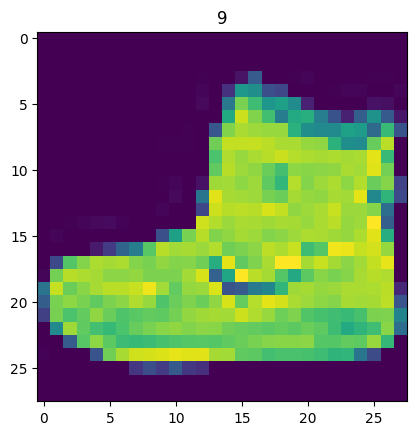

In [19]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze());
plt.title(label);

# plt.imshow() takes in a grid of numbers(a matrix or a NumPy array) and renders it as a visual image.
# If we try to pass a PyTorch tensor directly from our FashionMNIST dataset into `plt.imshow()`, we'll likely hit an error. 
# We can use `.permute()-rearrange the dimensions` or `.squeeze()` to squeeze out the channel dimension if its grayscale. 

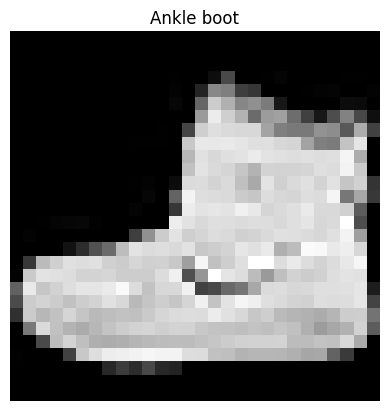

In [21]:
plt.imshow(image.squeeze(), cmap="gray");
plt.title(class_names[label]);
plt.axis(False);

### Regularization

- Regularization is a technique used to prevent ML models from `overfitting`.
- Regularization solves this by penalizing the model for making its coefficients(weights) too large or complex. It forces the model to stay simple.

* The Penalty Term:
  - In standard Linear regression the goal is to minimize the loss function(usually MSE)
    $$\text{Loss} = \text{MSE}$$
  - Regularization modifies this by adding a **penalty term** to the loss function:
    $$\text{Total Loss} = \text{MSE} + \alpha \times (\text{Penalty})$$
  - $\alpha$ (Alpha) / $\lambda$ (Lambda): It is a tuning patameter(hyperparameter) that controls how severely we want to penalize complexity.
    - If $\alpha = 0$, regularization is turned off(its just standard regression).
    - If $\alpha$ is extremely high, the penalty dominates, forcing the weights close to zero, which can lead to `underfitting`

1. `L1 Regularization(Lasso Regression)`:
   - **Lasso** stands for *Least Absolute Shrinkage and Selection Operator*
   - L1 regularization adds a penalty equal to the `absolute values` of the coefficients(w):
     $$\text{Total Loss} = \text{MSE} + \alpha \sum_{j=1}^{n} |w_j|$$
   - Key Characteristics(Feature Selection(Sparsity):
     * L1 regularization has a fascinating mathematical property: it **drives the weights of less important features exactly to zero**.
     * If we have 100 features, but only 5 of them actually matter, Lasso will zero out the other 95. This makes L1 excellent for `feature selection` and creating `sparse models`(model with few non-zero weights) that are highly interpretable and memory-efficient.
2. `L2 Regularization(Ridge Regression)`:
   - **Ridge** regression is also known as Tikonov regularization
   - L2 regularization adds a penalty equal to the `squared values` of the coefficients(w):
     $$\text{Total Loss} = \text{MSE} + \alpha \sum_{j=1}^{n} w_j^2$$
   - Key Characteristic(Coefficient Shrinkage):
     * Unlike L1, L2 regularization **never drives weights to zero**. Instead it shrinks all coefficients evenly toward zero, ensuring no single feature has a massive, disproportionate impact on the prediction.
     * It is highly effective when we have many features that are all slightly useful, or when features suffer from *multicollinearity*(meaning out input features are highly correlated with each other). Ridge will distribute the weight across those correlated features rather than picking one and discarding the others.

* Geometric Intuition: Why Lasso Zeroes Out Weights
  - To understand why L1 zeroes out weights while L2 only shrinks them, imagine a model with just two weights, $w_1$ and $w_2$.
    * L1 (Lasso) creates a diamond-shaped constraint. The mathematical "budget" for weights looks like a square tipped on its side. The optimization path of the loss function is highly likely to hit this constraint at one of the sharp corners—where one of the axes is exactly zero.
    * L2 (Ridge) creates a circular constraint. The budget looks like a smooth ball. The optimization path can hit this circle anywhere, meaning both $w_1$ and $w_2$ will likely retain small, non-zero values.

| Feature               | L1 Regularization (Lasso)                                | L2 Regularization (Ridge)           |
|-----------------------|----------------------------------------------------------|-------------------------------------|
| Penalty Term          | Absolute values ($\sum |w|$)                             | Squared values ($\sum w^2$)         |
| Can weights become 0? | Yes (Generates sparse models)                            | No (Weights get close to 0, but never exactly 0)| 
| Primary Use Case      | Feature selection, interpretability                      | Handling multicollinearity, general overfitting | 
| Computational Care    | Non-differentiable at zero (requires coordinate descent) | Easily differentiable (analytical closed-form solution exists) |


* If we cant decide between L1 and L2 for a particular case we can use `Elastic Net`. It combines both penalties into a single loss function, using a mixing ratio to balance between driving weights to zero(L1) and shrinking them smoothly(L2).

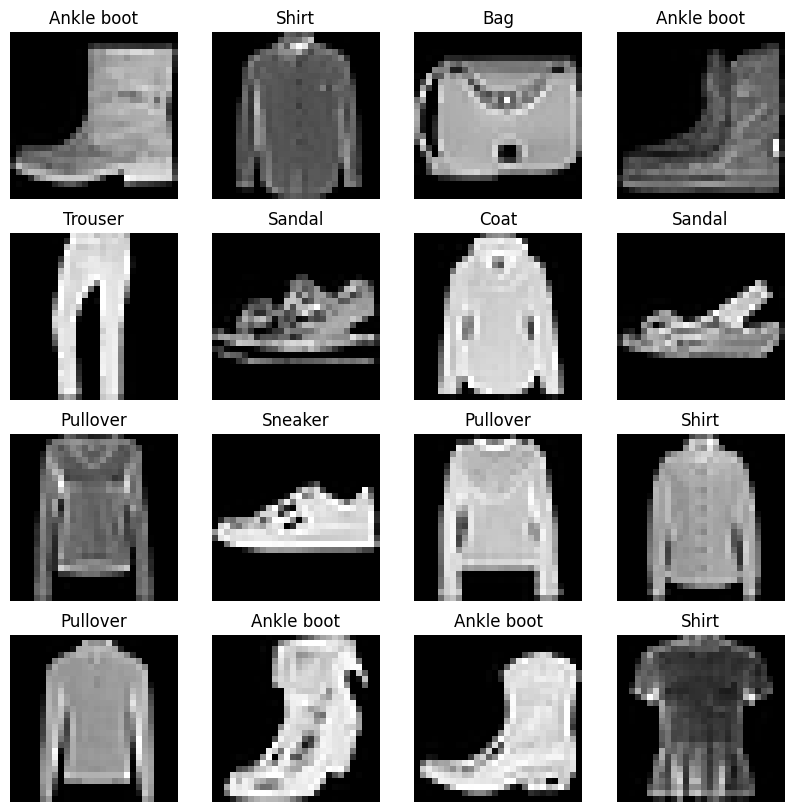

In [22]:
# Plot more images
torch.manual_seed(42)

fig = plt.figure(figsize=(10, 10))  #10in x10in
rows, cols = 4, 4 # 16 images
for i in range(1, rows*cols+1):  #matplotlib indexing starts at 1(not 0) so range is starting from 1 to 17(exclusive)
    random_idx = torch.randint(0, len(train_data), size=[1]).item() #random integer between 0 and len(train_data) which is 60k and .item extracts the exact value like 42107 here.
    # print(random_idx) # size=[1]: "Give me a 1-D tensor that contains exactly one element"(single number wrapped inside a tensor like tensor([42107]))
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)  # Divide my canvas into a 4x4 grid and activate the i-th slot. It moves from top-left slot to bottom-right slot.
    plt.imshow(img.squeeze(), cmap="gray") #.squeeze() removes unnecessary color channel dimension
    plt.title(class_names[label]);
    plt.axis(False); #hides the x and y axis 

So these items of clothing(images) could be modelled with pure linear lines? Or we'll need non-linearities? Let's see.

## 2. Prepare DataLoader

Right now, our data is in the form of PyTorch datasets.

DataLoader turns our dataset into a Python iterable.

More specifically, we want to turn our data into batches(or mini-batches).

But why we need to do this?

1. It is more computationally efficient, as in, our computing hardware mayn't be able to look(store in memory) at 60000 images in one hit. So we break it down to 32 images at a time (batch size of 32-most common)
2. It gives our neural network more chances to update its gradients per epoch.

In [23]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [24]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(dataset = train_data,
                             batch_size = BATCH_SIZE,
                             shuffle = True) # shuffle by default is False

# shuffle = true as to mix up all the samples as we dont want to learn the order of images in our dataset
#   (switch from 1 image category to another becomes tuff as image 2 category model again and again tries to correct 
#     the weights and parameters to match as per previous image category)
# shuffle = true: breaks the order bias

test_dataloader = DataLoader(dataset = test_data,
                            batch_size = BATCH_SIZE,
                            shuffle = False) 
# Its generally better to not shuffle (easier to debug as in each run the order remains same, we can find out 
#     specific images at which the model is failing)

# len(train_dataloader) -> 60000/32=1875 # len(test_dataloader) -> 10000/32= 312.5=313
# train_dataloader and test_dataloaders are iterables here
train_dataloader, test_dataloader, len(train_dataloader), len(test_dataloader)

(<torch.utils.data.dataloader.DataLoader at 0x7d80b27ff0b0>,
 1875,
 313)

In [25]:
# Let's check out what we've created
print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length of train_dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}...")
print(f"Length of test_dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}...")

# dataloader.drop_last drops the last batch
# dataloader.pin_memory pins the memory which helps in loading our data faster.

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x7d80b27ff0b0>, <torch.utils.data.dataloader.DataLoader object at 0x7d80b39bd5b0>)
Length of train_dataloader: 1875 batches of 32...
Length of test_dataloader: 313 batches of 32...


In [26]:
# Check out whats inside the training dataloader (Grabbing a Single Batch)
train_features_batch, train_features_label = next(iter(train_dataloader)) 
train_features_batch.shape, train_features_label.shape

# DataLoader is an iterable object it doesnt load all the memory at once, it prepares it to looped through.
# iter(train_dataloader) turns the dataloader into a Python iterable(essentially putting it at a starting line)
# next(...) manually pulls the very first item out of that iterator. In this case, its a single batch of data
# 32 images of size [1,28,28] and 32 labels as batch_size is 32

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [27]:
len(train_features_batch), len(train_features_label)

(32, 32)

## 3. Model 0: Build a baseline Model

When starting to build a series of Machine Learning modelling experiments, it's best practice to start with a baseline model.

A baseline model is a simple model we'll try and improve upon with subsequent models/experiments.

In other words: start simply and add complexity when necessary.

Image Shape: torch.Size([1, 28, 28])
Label: 1, label size: torch.Size([])
Label_name: Trouser


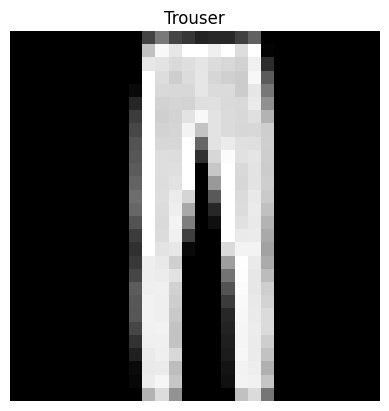

In [29]:
# Show a sample
# torch.manual_seed(42)
# This is for the same 1 batch, the results we're getting
# Pulling out a Sample out of that batch(1 out of 32 images)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_features_label[random_idx] # it grabs the i-th image and its matching label out of the batch of 32 images
plt.imshow(img.squeeze(), cmap = "gray")
plt.title(class_names[label])
plt.axis(False)
print(f"Image Shape: {img.shape}")
print(f"Label: {label}, label size: {label.shape}") 
# label is a scalar as we sliced single value out of 1D tensor(train_features_label[random_idx] isnt an array its a single number)
print(f"Label_name: {class_names[label]}")

In [30]:
# Create a flatten layer
flatten_model = nn.Flatten() 

# Get a single sample
x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x) 

# Print out whats happened
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")

# The purpose of nn.Flatten()  is to compress a multi-dimensional tensor(like an image) into a single one-dimensional vector without losing 
# any of the underlying data.

# While working with image datasets our data travels through the network as a 3D/4D tensor. [32,1,28,28] is a single image batch from dataloader
# However, standard linear layers (nn.Linear()) which make up the decision making tail-end of our neural network are mathematically designed
#   to take in 1D "feature vectors" per sample. They expect an input shape of [32, Features]. So if we throw a 4D tensor into nn.Linear() 
#   PyTorch will throw a big "Shape Mismatch Error"

## nn.Flatten() takes all the pixel dimension and multiplies them together to unravel the image into a long line of numbers. By default
#   it "preserves the batch dimension(dimension 0)" because it knows we dont want to mix different images together. It only flattens the 
#   dimension after the batch.
#   [32,1,28,28] will be converting into [32,784]

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


In [31]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, 
                 input_shape = int,
                 hidden_units = int,
                 output_shape = int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # first flatten the data to pass into Linear layer 
            nn.Linear(in_features = input_shape, out_features = hidden_units),
            nn.Linear(in_features = hidden_units, out_features = output_shape)
        )
    def forward(self, x):
        return self.layer_stack(x)

In [32]:
torch.manual_seed(42)

# Setup model with input parameters
model_0 = FashionMNISTModelV0(
    input_shape = 28*28,
    hidden_units = 10, #units in hidden layer
    output_shape = len(class_names) # one for every layer
)
model_0.to(device)

# in model_0 start_dim=1 means from NCHW leave 0th dimension N bcoz if we flatten this then the model cant keep track of any image
#    start and end, (32x1x28x28=25088). Thats why leave dim0
# end_dim=-1(the last dimension width here) flatten it (32,1,28,28) flattens to (32,1,28*28)

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [33]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x.to(device)), model_0(dummy_x.to(device)).shape

(tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
          -0.1004,  0.0157]], device='cuda:0', grad_fn=<AddmmBackward0>),
 torch.Size([1, 10]))

In [34]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]],
                     device='cuda:0')),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163], device='cuda:0')),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0

### 3.1 Setup loss, optimizer and evaluation metrics

* Loss Function - since we're working with multi-class data, our loss function will be `nn.CrossEntropyLoss()`
* Optimizer - our optimizer will be `torch.optim.SGD()`(Stoicastic Gradient Descent) or `torch.optim.Adam()`
* Evaluation metric - since we're working on a classification problem, lets use accuray as our evaluation metric.

In [35]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo
if Path("helper_functions.py").is_file():
    print("helper_funcitons.py already exists, skipping download")
else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:  #open file with write binary permissions
        f.write(request.content)
    print("Downloaded")

Downloaded


In [36]:
# Import accuracy metrics from helper_functions.py
from helper_functions import accuracy_fn

# Setup Loss function and Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                           lr = 0.1)

### 3.2 Creating a function to time our experiments

Machine Learning is very experimental.

Two main things we'll often want to track are:
1. Model's performance(loss and accuracy values etc)
2. How fast it runs

Usually we want a model which is High Performing and Fast(ideal scenario) but often there's a tradeoff between the two

In [37]:
from timeit import default_timer as timer
# its basically a display(time) function
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None): #we want to compare time of cpu and cuda so None here
    """Prints difference between start and end time."""
    total_time = end - start
    print(f"Train time on {device} : {total_time:.3f} seconds")
    return total_time

In [38]:
device

'cuda'

In [39]:
start_time = timer()
#some code....
end_time = timer()
print_train_time(start_time, end_time, device)

Train time on cuda : 0.000 seconds


2.9189999622758478e-05

### 3.3 Creating a training loop and training a model on batches of data

1. Loop through epochs.
2. Loop through training batches, perform training steps, calculate the train loss per batch.
3. Loop through testing batches, perform testing steps, calculate the test loss per batch.
4. Print out what's happening.
5. Time it all.

In [40]:
# Import tqdm for progress bar
# tqdm.auto is a wrapper and there're few types of tqdm and .auto recognises what computing environment we're using and gives us the best progress bar
#   (e.g: progress bar for jupyter notebooks is differnent from progress bar for python scripts)
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
# train_time_start_on_cpu = timer()
train_time_start_on_gpu = timer()

# Set the number of epochs(we'll keep this small for faster training time)
epochs = 10

# Create training and test loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-----")
    ## Training
    train_loss , train_acc = 0, 0 #resetting both to 0 at start of every epoch so metrics from epoch 2 dont add to epoch 1
    #instantiate train_loss with 0 to accumulate it to count training loss per batch(then find avg. training loss per batch then per epoch)

    # enumerate() gives us the integer index of the current batch(stored in batch variable) starting at 0. X is a tensor bundle of our images
    # (e.g shape [32,1,28,28]), and y contains their matching true labels(shape[32])
    # Add a loop to loop through the training batches
    model_0.train() #train simply sets model to training mode, so need to set outside batch loop as we need to declare this once per epoch
    for batch, (X,y) in enumerate(train_dataloader): #(X,y) is (image,label) 
        # Move images(X) and labels(y) to the GPU
        X,y = X.to(device), y.to(device)
        #1. Forward pass
        y_pred = model_0(X)

        #2. Calculate the loss(per batch) and accuracy
        loss = loss_fn(y_pred, y)
        train_loss += loss # we're accumulating the training loss then we'll divide it by no.of batches to get the avg. loss per batch

        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1)) #y_pred is logits but accuracy function expects prediction labels

        #3. Optimizer zero grad(clears out the old gradients so they dont interfere with the next batch)
        optimizer.zero_grad()

        #4. Loss backward
        loss.backward()

        #5. Optimizer step(optimizer.step() actually updates our model's weight and biases)
        optimizer.step() ## Optimizer will update a model's parameters once per batch now rather than once per epoch...
                                               #(which allows the model to learn and adapt much faster)

        # print out what's happening
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)} / {len(train_dataloader.dataset)} samples.") #len(X) is 32
            
    # Divide the total loss by length of train dataloader(to calculate loss per batch)
    train_loss /= len(train_dataloader)

    train_acc /= len(train_dataloader)

    ## Testing
    test_loss, test_acc = 0,0
    model_0.eval()
    with torch.inference_mode():
        for (X_test, y_test) in test_dataloader:  # as we're NOT using batch index in testing loop we can remove enumaerate
            # Move test data to the GPU
            X_test, y_test = X_test.to(device), y_test.to(device)
            #1. Forward Pass
            test_pred = model_0(X_test)

            #2. Calculate the loss (accumulatively)
            test_loss += loss_fn(test_pred, y_test)

            #3. Calculte accuracy
            test_acc += accuracy_fn(y_true = y_test, y_pred = test_pred.argmax(dim=1)) #test_pred is logits but accuracy function expects prediction labels

        # Calculate the test loss average per batch
        test_loss /= len(test_dataloader)

        # Calculate the test acc average per batch
        test_acc /= len(test_dataloader)

    # Print out what's happening
    print(f"Train loss: {train_loss:.4f}, Training accuracy: {train_acc:.4f}% | Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}\n")

# Calculate the training time
# train_time_end_on_cpu = timer()
train_time_end_on_gpu = timer()
total_train_time_model_0 = print_train_time(start = train_time_start_on_gpu,
                                            end = train_time_end_on_gpu,
                                            device = str(next(model_0.parameters()).device)) 
#checks our model's parameter's are in which device and converts the device objects into simple string so it can be passed to device parameter
# inside print_train_time function

# train time on cpu alone was 110+ seconds and gpu its 88.5 seconds(low data volume, data transfer to GPU bottleneck, dataloader overhead)
# enumerate is ude in training and not testing because we explicitly need to track the index number of trianing batch to check which 
#    batch we're in, without it we cant print the Looked at ... out of ...  samples.
#   and we're not printing something like that in testing so we dont need it in testing

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
-----
Looked at 0 / 60000 samples.
Looked at 12800 / 60000 samples.
Looked at 25600 / 60000 samples.
Looked at 38400 / 60000 samples.
Looked at 51200 / 60000 samples.
Train loss: 0.5904, Training accuracy: 79.1717% | Test loss: 0.5095, Test acc: 82.0387

Epoch: 1
-----
Looked at 0 / 60000 samples.
Looked at 12800 / 60000 samples.
Looked at 25600 / 60000 samples.
Looked at 38400 / 60000 samples.
Looked at 51200 / 60000 samples.
Train loss: 0.4763, Training accuracy: 83.3200% | Test loss: 0.4799, Test acc: 83.1969

Epoch: 2
-----
Looked at 0 / 60000 samples.
Looked at 12800 / 60000 samples.
Looked at 25600 / 60000 samples.
Looked at 38400 / 60000 samples.
Looked at 51200 / 60000 samples.
Train loss: 0.4550, Training accuracy: 84.0517% | Test loss: 0.4766, Test acc: 83.4265

Epoch: 3
-----
Looked at 0 / 60000 samples.
Looked at 12800 / 60000 samples.
Looked at 25600 / 60000 samples.
Looked at 38400 / 60000 samples.
Looked at 51200 / 60000 samples.
Train loss: 0.4425, Training acc

### the above time is time for gpu, for cpu its 110 seconds

In [41]:
len(train_dataloader), len(test_dataloader), str(next(model_0.parameters()).device)

(1875, 313, 'cuda:0')

## 4. Make predictions and get Model_0 results

In [42]:
# Functioning evaluation loop
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn: accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader."""
    loss, acc = 0, 0

    # Dynamically find out what the model is currently using
    device = next(model.parameters()).device
    
    model.eval()
    with torch.inference_mode():
        # Added tqdm just in case tqdm isnt globally available
        from tqdm.auto import tqdm
        
        for X, y in tqdm(data_loader):
            # Send data to target device (same device as the model)
            X, y = X.to(device), y.to(device)
            
            # Make Predictions
            y_pred = model(X)

            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true = y,
                               y_pred = y_pred.argmax(dim=1))

        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name" : model.__class__.__name__, # only works when model was created with a class
            "model_loss" : loss.item(), # .item() converts 1-element tensor to a python float
            "model_acc": acc}
# (.__class__) looks out for original blueprint of the Class structure that generated it(e.g: <class '__main__.FashionMNISTModelV0')
# (.__name__) Python after looking the class template .__name__ strips the raw test name of the class defintion and 
#             returns the literal(e.g: FashionMNISTModelV0)

# Calculate model_0 results on test dataset
model_0_results = eval_model(model = model_0,
                            data_loader = test_dataloader,
                            loss_fn = loss_fn,
                            accuracy_fn = accuracy_fn)
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4627982974052429,
 'model_acc': 83.64616613418531}

## 5. Setup device agnostic-code(for using a GPU if there's one)

In [43]:
!nvidia-smi

Fri May 29 19:17:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             30W /   70W |     161MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [44]:
# Setup device - agnostic code
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 6. Model 1: Building a better model with non-linearity

In [45]:
# Create a model 
from torch import nn
class FashionMNISTModelV1(nn.Module):
    def __init__(self,
                 input_shape : int,
                 hidden_units : int,
                 output_shape : int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # flattern inputs into a single vecctor
            nn.Linear(in_features = input_shape, out_features = hidden_units),
            nn.ReLU(),
            nn.Linear(in_features = hidden_units, out_features = output_shape),
            nn.ReLU()
        )
    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

In [46]:
# Create an instance  of model_1
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape = 784, # this is the output of the flatten after image goes in
                              hidden_units = 10,
                              output_shape = len(class_names)).to(device) #send to gpu if available
next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.1 Setup loss, optimizer and evaluation metrics

In [47]:
# Create a loss function and optimizer
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss() # measure how wrong our model is
optimizer = torch.optim.SGD(params=model_1.parameters(), #tries to update our model's parameters to reduce the loss
                             lr = 0.1)

### 6.2 Functionizing and evaluation/testing loops

Let's create a function for:
* training loop - `train_step()`
* testing loop - `test_step()`

In [48]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    
    """Performs a training with model trying to learn on data_loader."""
    train_loss, train_acc = 0, 0

    # Put the model into training model
    model.train()

    # Add a loop to loop through the training batches
    for batch, (X,y) in enumerate(data_loader):
        # Put data on the target device
        X, y = X.to(device), y.to(device)
        
        #1. Forward Pass(outputs raw logits from the model)
        y_pred = model(X)

        #2. Calculate the loss and accuracy (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss #accumulate the train loss
        train_acc += accuracy_fn(y_true = y,
                                 y_pred = y_pred.argmax(dim=1)) # go from logits -> prediction labels

        #3. Optimizer Zero Grad
        optimizer.zero_grad()

        #4. Loss Backward
        loss.backward()

        #5. Optimizer Step
        optimizer.step()

    # Divide total train_loss and train_acc by the length of train dataloader
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%")

In [49]:
def test_step(model: torch.nn.Module,
              data_loader : torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device): #we're not performing any optimization step in testing loop so we dont need an optimizer
    
    """Performs a testing on model going ovet data_loader"""
    test_loss, test_acc = 0, 0
    
    # Put the model into eval mode
    model.eval()

    # Turn on inference mode context manager
    with torch.inference_mode():
        for (X, y) in data_loader:
            # Send data to the target device
            X, y = X.to(device), y.to(device)

            #1. Forward Pass(outputs raw logits)
            test_pred = model(X)

            #2. Calculate the test loss and test acuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true = y,
                                   y_pred = test_pred.argmax(dim=1)) # go from logits -> prediction labels


        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%\n")

In [50]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

# Set epochs
epochs = 10

# Create a optimization and evaluation loop using train_step() and test_step()
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-----")
    
    train_step(model = model_1, 
               data_loader = train_dataloader,
               loss_fn = loss_fn,
               optimizer = optimizer,
               accuracy_fn = accuracy_fn,
               device = device)

    test_step(model = model_1, 
              data_loader = test_dataloader,
              loss_fn = loss_fn,
              accuracy_fn = accuracy_fn,
              device = device)

train_time_end_on_gpu = timer()

total_train_time_model_1 = print_train_time(start = train_time_start_on_gpu,
                                            end = train_time_end_on_gpu,
                                            device = device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
-----
Train loss: 1.09199 | Train acc: 61.34%
Test loss: 0.95636 | Test acc: 65.00%

Epoch: 1
-----
Train loss: 0.78101 | Train acc: 71.93%
Test loss: 0.72227 | Test acc: 73.91%

Epoch: 2
-----
Train loss: 0.67027 | Train acc: 75.94%
Test loss: 0.68500 | Test acc: 75.02%

Epoch: 3
-----
Train loss: 0.64384 | Train acc: 76.52%
Test loss: 0.65079 | Test acc: 76.13%

Epoch: 4
-----
Train loss: 0.62892 | Train acc: 77.00%
Test loss: 0.65277 | Test acc: 75.95%

Epoch: 5
-----
Train loss: 0.61569 | Train acc: 77.43%
Test loss: 0.64517 | Test acc: 76.54%

Epoch: 6
-----
Train loss: 0.60672 | Train acc: 77.80%
Test loss: 0.62879 | Test acc: 76.67%

Epoch: 7
-----
Train loss: 0.47136 | Train acc: 83.09%
Test loss: 0.44768 | Test acc: 84.30%

Epoch: 8
-----
Train loss: 0.39947 | Train acc: 85.96%
Test loss: 0.44110 | Test acc: 84.75%

Epoch: 9
-----
Train loss: 0.39380 | Train acc: 86.17%
Test loss: 0.43291 | Test acc: 84.82%

Train time on cuda : 91.115 seconds


In [51]:
model_1_results = eval_model(model = model_1,
                            data_loader = test_dataloader,
                            loss_fn = loss_fn,
                            accuracy_fn = accuracy_fn)
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.4329094886779785,
 'model_acc': 84.82428115015975}

In [52]:
model_0_results, model_1_results

({'model_name': 'FashionMNISTModelV0',
  'model_loss': 0.4627982974052429,
  'model_acc': 83.64616613418531},
 {'model_name': 'FashionMNISTModelV1',
  'model_loss': 0.4329094886779785,
  'model_acc': 84.82428115015975})

#### Adam optimizer and last ReLU layer can completely shutoff the results, its too bad. SGD might work as it is far less aggressive than Adam. Putting ReLU as last layer wipes out all the -ve outputs so if model outputs all 10 categories -ve ReLU scales all of them to 0. So loss function crossentropyloss gets completely confused and gradients break(dying ReLU problem), and the model's weight freeze up.

In [53]:
# Better Model
# class FashionMNISTModelV2(nn.Module):
#     def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
#         super().__init__()
        
#         # 1. Feature Extractor (Convolutional Blocks)
#         self.block_1 = nn.Sequential(
#             nn.Conv2d(in_channels=input_shape, # 1 for grayscale
#                       out_channels=hidden_units, 
#                       kernel_size=3, 
#                       stride=1, 
#                       padding=1),
#             nn.ReLU(),
#             nn.Conv2d(in_channels=hidden_units, 
#                       out_channels=hidden_units,
#                       kernel_size=3,
#                       stride=1,
#                       padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2, stride=2) # Compresses image dimensions by half
#         )
        
#         self.block_2 = nn.Sequential(
#             nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2)
#         )
        
#         # 2. Classifier Head (Fully Connected Layers)
#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             # After two MaxPool2d operations, a 28x28 image scales down to 7x7
#             nn.Linear(in_features=hidden_units * 7 * 7, out_features=output_shape)
#             # CRITICAL: No ReLU at the absolute end here!
#         )
        
#     def forward(self, x: torch.Tensor):
#         x = self.block_1(x)
#         x = self.block_2(x)
#         x = self.classifier(x)
#         return x

---

**Note:** Sometimes, depending on our data/hardware we might find that our model trians faster on CPU than GPU.

Why? 
  1. It could be that the overhead for copying data/model to and from the GPU outweights the compute benefits offered by the GPU
  2. The hardware we're using  has a better CPU in terms of compute capability than the GPU.

https://horace.io/brrr_intro.html

## Model 2: Building a Convolutional Neural Network(CNN)

CNN's are also known as ConvNets.

CNN's are known for their capabilities to find patterns in visual data.

VGG(Visual geometry Group) has 2 structrures VGG-16/ VGG-19
- VGG-16(13 convolutional and 3 dense layers)
- VGG-19(16 convolutional and 3 dense layers)

The number of layer count takes into account only convolutional and dense/fully connected layers because these are the only layers with learnable parameters.

While the pooling layers have **patameter-free** operations used solely for downsampling spatial dimensions.(VGG-16 and 19 have 5 maxpool layers that is not taken into account)

VGG-16:
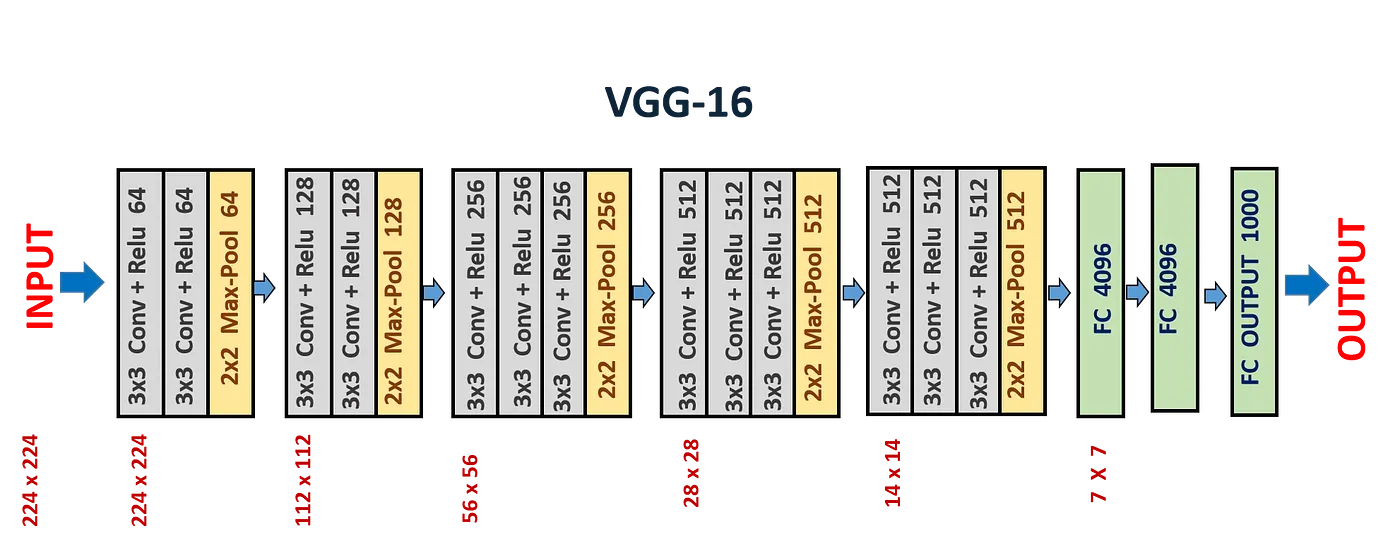

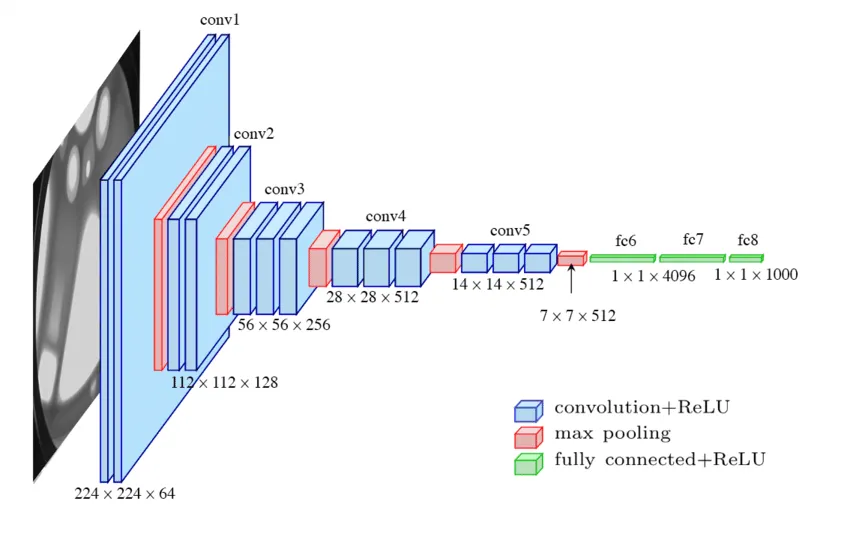

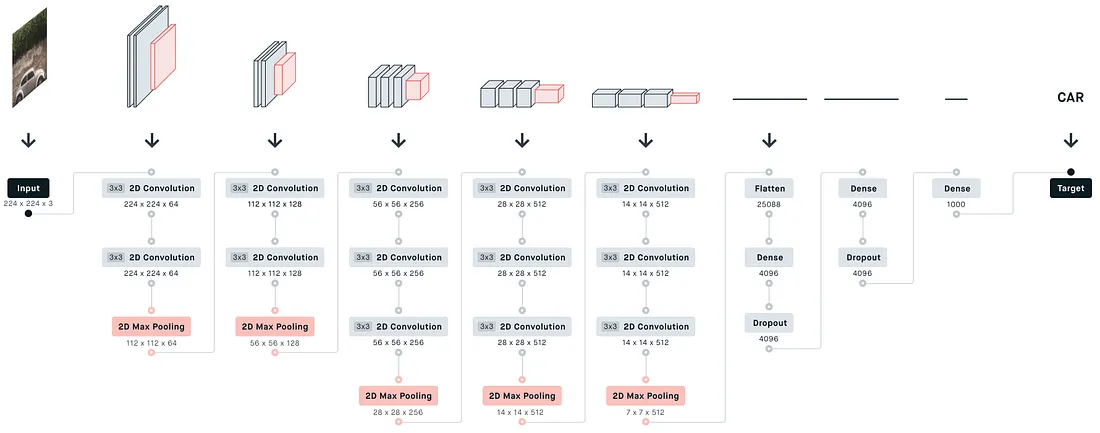

64, 128, 256, 512 are the number of filters/hidden units(multiply by 2 each forward layer)

#### Tiny VGG - Architecture:
* block1(Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool)
* block2(Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool)
* classifier_head(Flatten -> Linear(dense))

so VGG-5(4 conv + 1 fc layer)


* **BatchNorm** has learnable scale and shift parameters, though it usually not added to the structural layer count. 

In [54]:
# Classifier block is the final comonent that transorms the extracted features into class predicitons. It typically consisits of dense(fc) 
# layers followed by an output layer with an activation function like Softmax/Sigmoid.

# input channels refer to the distinct feature maps or dimensions of the input data tensor, typically corresponding to color 
#  components in images like 3 channels(R,G,B) for RGB and 1 channel for grayscale

# Kernel(a filter) in CNN is a small trainable matrix of weight that slides across input data, such as image to extract local features.

# Stride is the number of pixels the kernel moves across the input image or feature map at each step of convolution operation.

# Padding refers to the process of adding extra pixels(typically 0s) around border of an input image or feature map before applying a 
# convolutional filter because the convolution operations inherently reduce the spatial dimensions of the output, so without padding, the 
# feature map shrinks, causing a loss of edge information and uneven usage of boundary pixels.

# Convolutional Block(or simply Block) is a modular, reusable structural unit consisting of a sequence of layers grouped together to 
# perform a specific feaure-extraction task.
# Classic block looks like(Convolutional Layer, Activation Function, Normalization, Pooling Layer)
                


# Batch size of 1(lets assume) and 1 Image (hidden_units=10, input_shape=1, output_shape=10)
#                                      [1,1,27+1,27+1](padding)
# * Input: [1,1,28,28] -> block1(Conv2d : [1,10,28,28] -> ReLU : [1,10,28,28] -> Conv2d : [1,10,28,28] 
#           -> ReLU : [1,10,28,28] -> MaxPool : [1,10,14,14])
# * block2(Conv2d : [1,10,14,14] -> ReLU : [1,10,14,14] -> Conv2d : [1,10,14,14] -> ReLU : [1,10,14,14]  -> MaxPool : [1,10,7,7])
# * classifier_head(Flatten[1,10*7*7] -> Linear(dense)[1,10])

In [55]:
# Create a Convolutional Neural Network
class FashionMNISTModelV2(nn.Module):
    """
    Model architecture that replicates the TinyVGG model
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        # Create a conv layer
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels = input_shape,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1, 
                      padding = 1), #in_channels: channels refer to the channels in our visual data
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2) #same as kernel_size = (2,2) 2x2 matrix
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels = hidden_units,  # MaxPool changes changes spatial dimensions(Height and width) not the number of channels(color, 
                                                    # later change into hidden_units as they pass through conv layers)
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = hidden_units*7*7, #temporarily done to not throw error(0)
                      out_features = output_shape)
        ) 

    def forward(self, x):
        x = self.conv_block_1(x)
        # print(f"Output shape of conv_block_1: {x.shape}")
        x = self.conv_block_2(x)
        # print(f"Output shape of conv_block_2: {x.shape}")
        x = self.classifier(x)
        # print(f"Output shape of classifier: {x.shape}")
        return x
        
#(if another pool layer floor(7/2)=3 then another floor(3/2)=1 then (1/2)=0 and PyTOrch crash as we cant run a conv or pool operaion on an empty 0x0 map)

In [56]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape = 1,   #our image shape is [1,28,28] so input shape must be equal to number of channels i.e 1
                              hidden_units = 10,
                              output_shape = len(class_names)).to(device)
model_2

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

torch.Size([1, 28, 28])


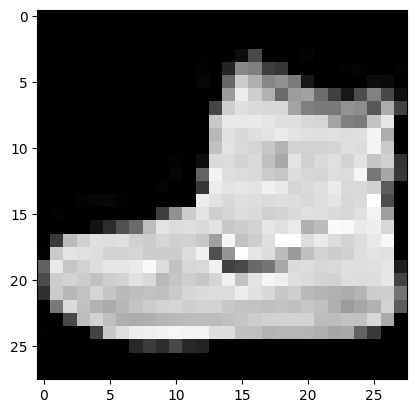

In [57]:
print(image.shape)
plt.imshow(image.squeeze(), cmap="gray");

In [58]:
image_on_gpu = image.to(device)
model_2(image_on_gpu.unsqueeze(0))

tensor([[ 0.0246, -0.0644,  0.0551, -0.0360, -0.0139,  0.0113, -0.0014, -0.0075,
          0.0213,  0.0076]], device='cuda:0', grad_fn=<AddmmBackward0>)

### 7.1 Stepping through `nn.Conv2d()`

`torch.nn.Conv2d(in_channels=3, out_channels=10, kernel_size(3,3), stride = (1,1), padding = 0)`:

| Hyperparameter | What does it do?                                                            | Typical Values                       |
|----------------|-----------------------------------------------------------------------------|--------------------------------------|
|in_channels     | Defines the number of input channels of the input data                      | 1(grayscale), 3(RGB clor images)     |
|out_channels    | Defines the output channels of the layer(also calles hidden units)          | 10, 128, 256, 512                    |
|kernel_size(also referred to as filter size)| Determines the shape of the kernel(sliding windows) over the input | 3, 5, 7 (lower values learn small features, higher values learn larger features  |
|stride          | The number of steps a filter takes across an image at a time(e.g. if `strides=1`, a filter moves across an image 1 pixel at a time | 1(default), 2 |
|padding         | Pads the target tensor with zeroes(if "same") to preserve input shape. Or leaves in the target tensor as is(if "valid", lowering output shape | 0, 1, "same", "valid" (same(1)-preserves input shape and valid(0)-leaves tensor as it is)|


In [59]:
torch.manual_seed(42)

# Create a batch of images
images = torch.randn(size = (32, 3, 64, 64))
test_image = images[0]

print(f"Image batch shape: {images.shape}")
print(f"Single image shape: {test_image.shape}")
print(f"Test image:\n {test_image}")

Image batch shape: torch.Size([32, 3, 64, 64])
Single image shape: torch.Size([3, 64, 64])
Test image:
 tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0

In [60]:
test_image.shape

torch.Size([3, 64, 64])

In [61]:
torch.manual_seed(42)
# Create a single conv2d layer
conv_layer = nn.Conv2d(in_channels = 3,
                       out_channels = 10,
                       kernel_size = (3,3),  #same as 3 
                       stride = 1,
                       padding = 1)

# pass the data through the convolution layer
# conv_output = conv_layer(test_image.unsqueeze(0)) #output: torch.Size([1, 10, 62, 62])
conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 64, 64])

In [62]:
test_image.unsqueeze(0).shape

torch.Size([1, 3, 64, 64])

### 7.3 Setup a loss function and optimizer for model_2

In [63]:
# Setup loss function/eval metrics/optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_2.parameters(),
                            lr = 0.1)

### 7.4 Training and testing `model_2` using our training and test functions

In [64]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_on_device = timer()

# Set epochs
epochs = 10

# Create an optimization and evaluation loop using train_step() and test_step()
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch} \n---")
    train_step(model = model_2,
               data_loader = train_dataloader,
               loss_fn = loss_fn,
               optimizer = optimizer,
               accuracy_fn = accuracy_fn,
               device = device)
    
    test_step(model = model_2,
              data_loader = test_dataloader,
              loss_fn = loss_fn,
              accuracy_fn = accuracy_fn,
              device = device)

train_time_end_on_device = timer()

total_train_time_model_2 = print_train_time(start = train_time_start_on_device,
                                            end = train_time_end_on_device,
                                            device = device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0 
---
Train loss: 0.59109 | Train acc: 78.52%
Test loss: 0.38515 | Test acc: 86.51%

Epoch: 1 
---
Train loss: 0.35927 | Train acc: 87.00%
Test loss: 0.35024 | Test acc: 87.57%

Epoch: 2 
---
Train loss: 0.32033 | Train acc: 88.41%
Test loss: 0.31398 | Test acc: 88.73%

Epoch: 3 
---
Train loss: 0.29885 | Train acc: 89.23%
Test loss: 0.33140 | Test acc: 87.94%

Epoch: 4 
---
Train loss: 0.28626 | Train acc: 89.68%
Test loss: 0.30205 | Test acc: 89.32%

Epoch: 5 
---
Train loss: 0.27509 | Train acc: 90.09%
Test loss: 0.29754 | Test acc: 89.72%

Epoch: 6 
---
Train loss: 0.26654 | Train acc: 90.39%
Test loss: 0.29577 | Test acc: 89.44%

Epoch: 7 
---
Train loss: 0.26276 | Train acc: 90.47%
Test loss: 0.28831 | Test acc: 89.68%

Epoch: 8 
---
Train loss: 0.25437 | Train acc: 90.80%
Test loss: 0.30147 | Test acc: 89.56%

Epoch: 9 
---
Train loss: 0.24917 | Train acc: 90.93%
Test loss: 0.29789 | Test acc: 89.65%

Train time on cuda : 110.496 seconds


In [65]:
model_2_results = eval_model(model = model_2,
                             data_loader = test_dataloader,
                             loss_fn = loss_fn,
                             accuracy_fn = accuracy_fn)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.29789265990257263,
 'model_acc': 89.64656549520767}

In [66]:
model_2_results, model_1_results, model_0_results

({'model_name': 'FashionMNISTModelV2',
  'model_loss': 0.29789265990257263,
  'model_acc': 89.64656549520767},
 {'model_name': 'FashionMNISTModelV1',
  'model_loss': 0.4329094886779785,
  'model_acc': 84.82428115015975},
 {'model_name': 'FashionMNISTModelV0',
  'model_loss': 0.4627982974052429,
  'model_acc': 83.64616613418531})

## 8. Compare model results and training time

In [67]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results,
                                model_1_results,
                                model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.462798,83.646166
1,FashionMNISTModelV1,0.432909,84.824281
2,FashionMNISTModelV2,0.297893,89.646565


In [68]:
total_train_time_model_0, total_train_time_model_1, total_train_time_model_2

(90.6624482949992, 91.11517987000025, 110.49639060200025)

In [69]:
# Add training time to results comparision
compare_results["training time"] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2]
compare_results

,model_name,model_loss,model_acc,training time
0,FashionMNISTModelV0,0.462798,83.646166,90.662448
1,FashionMNISTModelV1,0.432909,84.824281,91.115180
2,FashionMNISTModelV2,0.297893,89.646565,110.496391


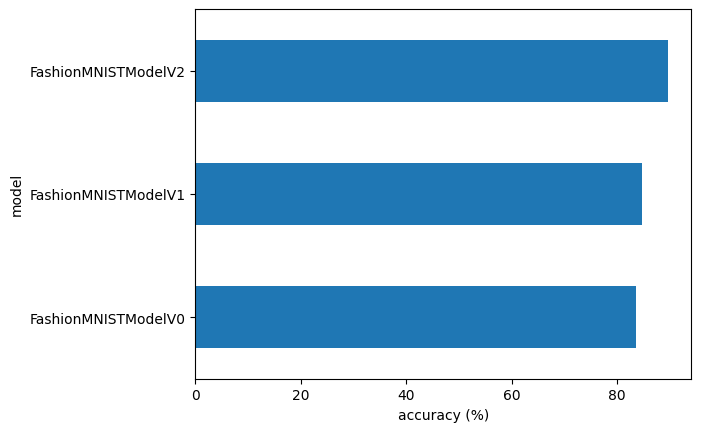

In [70]:
# Visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");

# By default dataframes use integers(0,1,2..) as their index(row labels). This funciton takes the values in "model_name" column and turns
#  them into the official row indexes of the dataframe

# ["model_acc"] This is used to visualize only this model_acc column out of all columns 

# kind kind tells the type of bargraph (barh-horizontal bar graph, bar-usual vertical bar graph)

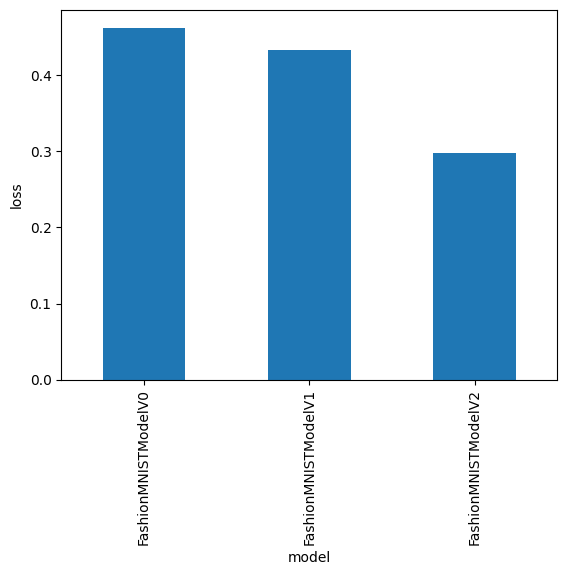

In [71]:
# Visualize our model results
compare_results.set_index("model_name")["model_loss"].plot(kind="bar")
plt.ylabel("loss")
plt.xlabel("model");

## 9. Make and evaluate random predictions with best model

In [72]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first sample shape
test_samples[0].shape, test_labels[0]

# list(test_data): PyTorch datasets are often cutom objects. Converting `test_data` to a standard Python list makes it compatible with the
#  standard random module. Each item inside this list is a tuple contaning an image tensor and its label: (image_tensor, label)

# random.sample(..., k=9) This function exactly picks 9 unique items from the dataset list completely at random 
# for sample, label : Tuple unpacking of (image_tensor, label)

(torch.Size([1, 28, 28]), 5)

In [73]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):
    pred_probs = []
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for sample in data: #processing the images one-by-one(sample is one image)
            # Prepare the sample (add a batch dimension and pass to target device)
            sample = torch.unsqueeze(sample, dim=0).to(device) #[1,28,28] to [1,1,28,28]

            # Forward Pass
            pred_logit = model(sample) #[1,1,28,28] -> [1,10](batch intact)

            # Get prediction probability(logits -> prediction probabilities) #as multiclass classification so softmax
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) #[1,10] -> [10] so dim=0

            # Get pred_prob off the GPU for further calculations(as matplotlibb works on cpu)
            pred_probs.append(pred_prob.cpu())

    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

# list=>inefficient, for calculating metrices like accuracy, precision single tenost needed 
# In list if we keep our predictions as a list of individual tensors then we have to look one by one through a for loop(a big time overhead
    # as Python loops are executed in cpu and are incredibly slow because they handle elements sequentially)
# torch.stack() combines individual rows into a single 2D matrix of shape [num_samples, num_classes]. It allows PyTorch to use "vectorized"
      # operations. It can calculate metrices across thousands of samples simultaneously thousands of time faster.
# Lists have scattered memory and uses pointer to locate actual memory location which is a massive performance bottleneck.
# Stack have contiguous memory, so no memory lookups bottleneck. 

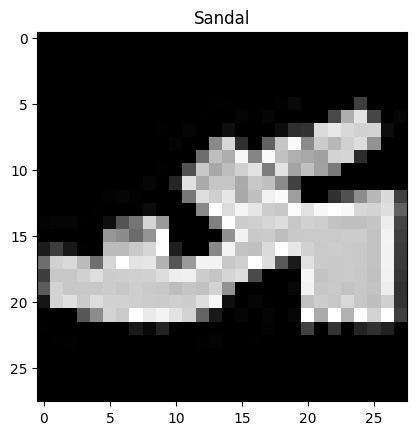

In [74]:
plt.imshow(test_samples[0].squeeze(), cmap="gray") #[1,28,28] to [28,28]
plt.title(class_names[test_labels[0]]);

In [75]:
test_samples[0].squeeze().shape

torch.Size([28, 28])

In [78]:
# Make predictions
pred_probs = make_predictions(model = model_2,
                              data = test_samples,
                              device = device)

# View first two predictions
pred_probs[:2], pred_probs.shape

(tensor([[2.5438e-09, 1.8885e-10, 2.4837e-09, 2.9174e-10, 1.1824e-09, 9.9994e-01,
          8.4273e-10, 1.0582e-06, 5.0988e-06, 5.5005e-05],
         [1.0239e-02, 9.6458e-01, 4.4733e-04, 2.3092e-02, 9.8394e-04, 1.1792e-05,
          4.8774e-04, 5.0769e-05, 1.0134e-04, 2.8341e-06]]),
 torch.Size([9, 10]))

In [79]:
# Convert prediction probabilities to labels
pred_classes = pred_probs.argmax(dim=1)
pred_classes, test_labels

(tensor([5, 1, 7, 4, 3, 6, 4, 7, 1]), [5, 1, 7, 4, 3, 0, 4, 7, 1])

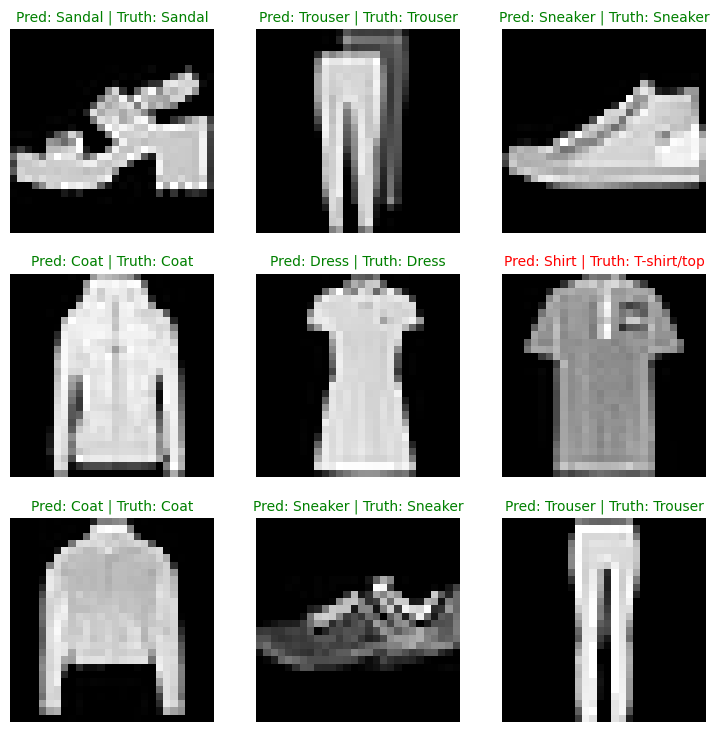

In [80]:
# Plot predictions
plt.figure(figsize=(9,9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
    # Create subplot
    plt.subplot(nrows, ncols, i+1)

    # Plot the target image
    plt.imshow(sample.squeeze(), cmap="gray")

    # Find the prediction(in text form, e.g. "Sandal")
    pred_label = class_names[pred_classes[i]]

    # Get the truth label(in text form)
    truth_label = class_names[test_labels[i]]

    # Create a title for the plot
    title_text = f"Pred: {pred_label} | Truth: {truth_label}"

    # Check for equality between pred and truth and change the color of title text
    if pred_label == truth_label:
        plt.title(title_text, fontsize = 10, c = "g") # green text if prediction same as truth
    else:
        plt.title(title_text, fontsize = 10, c = "r")

    plt.axis(False);

## 10. Make a confusion matrix for futher prediction evaluation

1. Make predictions with our trained model
2. Make a confusion matrix `torchmetrics.ConfusionMatrix`
3. Plot the confusion matrix using `mlextend.plotting.plot_confusion_matrix()`

`mlxtend` is specifically useful as a convenience wrapper to visualize a raw confusion matrix array instantly without configuring a heatmap manually. 
`mlxtend` plots a heatmap that can display both numbers simultaneously: *the absolute count (integer)* and *the normalized percentage* in the same cell unlike torchmetrics/seaborn.

In a professional PyTorch pipeline:
1. Use torchmetrics (or raw PyTorch) to accumulate your predictions into a final evaluation tensor.
2. Pass that resulting tensor to mlxtend to generate a clean, readable visual chart for your report or notebook.

In [81]:
# Make Predictions on whole test_dataset

# Import tqdm.auto
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
    for X,y in tqdm(test_dataloader, desc="Making predictions..."):
        # Send the data and targets to the target device
        X, y = X.to(device), y.to(device)
        # Do the forward pass
        y_logit = model_2(X) # o/p: [32,10](16 here as last batch)
        # Turn the predictions from logits -> prediction probabilities ->  predicition labels
        y_pred = torch.softmax(y_logit.squeeze(), dim=1).argmax(dim=1) 
        # Put the prediction on CPU for evaluation
        y_preds.append(y_pred.cpu())

# Concatenate list of predictions into a tensor
# print(y_preds)
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor

Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1,  ..., 8, 1, 5])

In [83]:
y_logit.shape, y_pred.shape #y_pred

(torch.Size([16, 10]), torch.Size([16]))

In [89]:
len(y_preds) #its a list of (313,32)

313

In [90]:
y_pred_tensor.shape #32+32+.....+16(313 times) concatenated into a long flat tensor making 10000

torch.Size([10000])

In [ ]:
# code to update some library to the latest version like mlxtend to 0.24.0 if present
#  (tried and it is causing compatibiilty issues but fine with default version so kept it)
# See if required packages are installed and if not, install them...
# try:
#     import torchmetrics, mlxtend
#     print(f"mlxtend version: {mlxtend.__version__}")
#     assert int(mlxtend.__version__.split("."))[1] >= 19, "mlxtend version should be 0.19.0 or higher"
# except:
#     !pip install -q torchmetrics -U mlxtend
#     import torchmetrics, mlxtend
#     print(f"mlxtend version: {mlxtend.__version__}")

In [91]:
import torchmetrics, mlxtend
torchmetrics.__version__, mlxtend.__version__

('1.9.0', '0.23.4')

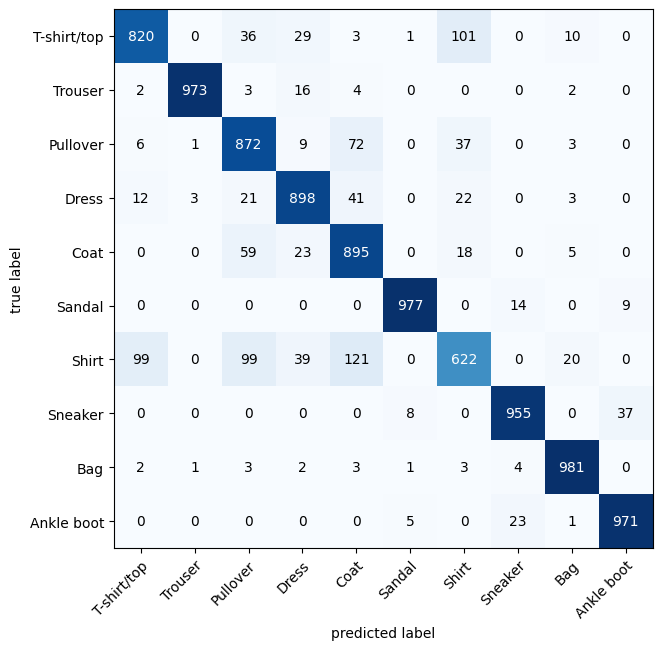

In [93]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup Confusion instance and compare predictions to targets
confmat = ConfusionMatrix(task="multiclass", num_classes = len(class_names))
confmat_tensor = confmat(preds = y_pred_tensor,
                         target = test_data.targets)

# 3. Plot the confusion matrix
fig, axes = plot_confusion_matrix(
    conf_mat = confmat_tensor.numpy(), #matplotlib is compatible with numpy unlike pytorch tensors
    class_names = class_names,
    figsize = (10,7)
)

In [94]:
from sklearn.metrics import classification_report

report = classification_report(y_true = test_data.targets.cpu().numpy(),
                               y_pred = y_pred_tensor.cpu().numpy(),
                               target_names = class_names)
print("---Classification Report Matrix---")
print(report)
# support is the actual number of true images belonging to that class in our dataset(1000 images per class here)

---Classification Report Matrix---
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.82      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.80      0.87      0.83      1000
       Dress       0.88      0.90      0.89      1000
        Coat       0.79      0.90      0.84      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.77      0.62      0.69      1000
     Sneaker       0.96      0.95      0.96      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.95      0.97      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.89     10000
weighted avg       0.90      0.90      0.89     10000



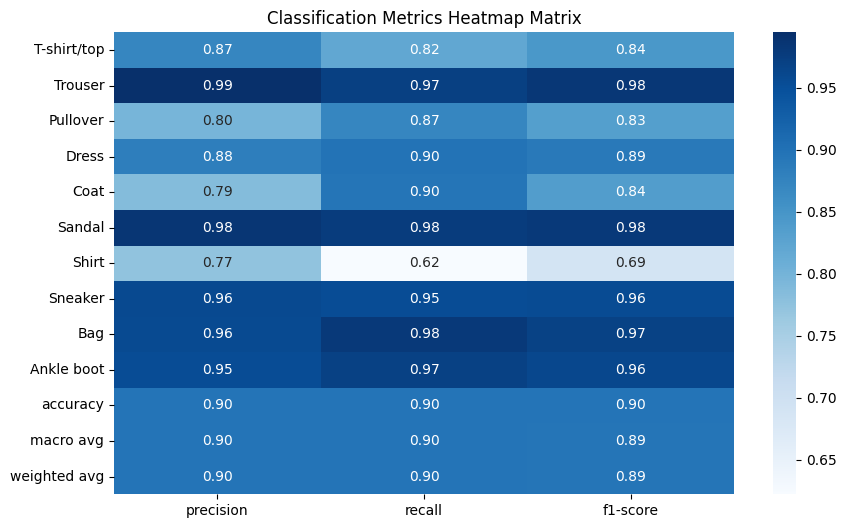

In [95]:
# Turn it into a Visual Heatmap (Optional)
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # 1. Output the report as a Python dictionary instead of text string
# dict_report = classification_report(y_true=test_data.targets.cpu().numpy(),
#                                     y_pred=y_pred_tensor.cpu().numpy(),
#                                     target_names=class_names,
#                                     output_dict=True)

# # 2. Convert to a Pandas DataFrame and drop total summary rows for cleaner mapping
# df_report = pd.DataFrame(dict_report).iloc[:-1, :].T

# # 3. Plot using a Seaborn heatmap grid
# plt.figure(figsize=(10, 6))
# sns.heatmap(df_report[['precision', 'recall', 'f1-score']], annot=True, cmap="Blues", fmt=".2f")
# plt.title("Classification Metrics Heatmap Matrix")
# plt.show()

In [98]:
confmat_tensor

tensor([[820,   0,  36,  29,   3,   1, 101,   0,  10,   0],
        [  2, 973,   3,  16,   4,   0,   0,   0,   2,   0],
        [  6,   1, 872,   9,  72,   0,  37,   0,   3,   0],
        [ 12,   3,  21, 898,  41,   0,  22,   0,   3,   0],
        [  0,   0,  59,  23, 895,   0,  18,   0,   5,   0],
        [  0,   0,   0,   0,   0, 977,   0,  14,   0,   9],
        [ 99,   0,  99,  39, 121,   0, 622,   0,  20,   0],
        [  0,   0,   0,   0,   0,   8,   0, 955,   0,  37],
        [  2,   1,   3,   2,   3,   1,   3,   4, 981,   0],
        [  0,   0,   0,   0,   0,   5,   0,  23,   1, 971]])

## 11. Save and load best performing model

In [100]:
from pathlib import Path

# Create model directory path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

# Create model save
MODEL_NAME = "mrdbourke_03_PyTorch_Computer_vision_model_2.pt"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# MODEL_SAVE_PATH
# Save the model's state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj = model_2.state_dict(),
           f = MODEL_SAVE_PATH)

Saving model to: models/mrdbourke_03_PyTorch_Computer_vision_model_2.pt


In [102]:
# Create a new instance
torch.manual_seed(42)

loaded_model_2 = FashionMNISTModelV2(input_shape = 1,
                                     hidden_units = 10,
                                     output_shape = len(class_names))

# Load in the saved model's state_dict()
loaded_model_2.load_state_dict(torch.load(f = MODEL_SAVE_PATH)) # output:<All keys matched successfully>

# Send the model to the target device
loaded_model_2.to(device)

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [103]:
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.29789265990257263,
 'model_acc': 89.64656549520767}

In [104]:
# Evaluate loaded model
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model = loaded_model_2,
    data_loader = test_dataloader,
    loss_fn = loss_fn,
    accuracy_fn = accuracy_fn
)

loaded_model_2_results #sometimes last numbers may differ due to precision, loading etc

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.29789265990257263,
 'model_acc': 89.64656549520767}

In [106]:
# Check if model results are close to each other
torch.isclose(torch.tensor(model_2_results["model_loss"]), 
              torch.tensor(loaded_model_2_results["model_loss"]),
              atol = 1e-02) #tolerance till 2 decimal places (if mismatch <0.01, tolerate it)

# atol is absolute tolerance 

tensor(True)

|Problem type| Model to use (generally)	| Code example |
|------------|--------------------------|--------------|
|Structured data (Excel spreadsheets, row and column data)	|Gradient boosted models, Random Forests, XGBoost  |	sklearn.ensemble, XGBoost library |
|Unstructured data (images, audio, language)  |  Convolutional Neural Networks, Transformers  |	 torchvision.models, HuggingFace Transformers |